In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.utils import get_processed_data_dir

from src.rfm import build_rfm

In [3]:
sales = pd.read_csv(
    get_processed_data_dir()
    / "online_retail_sales.csv",
    parse_dates=["InvoiceDate"]
)

/var/folders/ns/ms3xw2y52nj8x7n_3w_qw4tm0000gn/T/ipykernel_63553/4138439645.py:1: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv(


In [4]:
rfm = build_rfm(sales)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,165,11,372.86,2,5,2,252,At Risk
1,12347.0,3,2,1323.32,5,2,4,524,New Customers
2,12348.0,74,1,222.16,2,1,1,211,Lost Customers
3,12349.0,43,3,2671.14,3,3,5,335,Potential Loyalists
4,12351.0,11,1,300.93,5,1,2,512,New Customers


## Segment Distribution

In [5]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
)

segment_counts

Segment
Lost Customers         1015
Champions               926
Potential Loyalists     837
At Risk                 688
Loyal Customers         479
New Customers           367
Name: count, dtype: int64

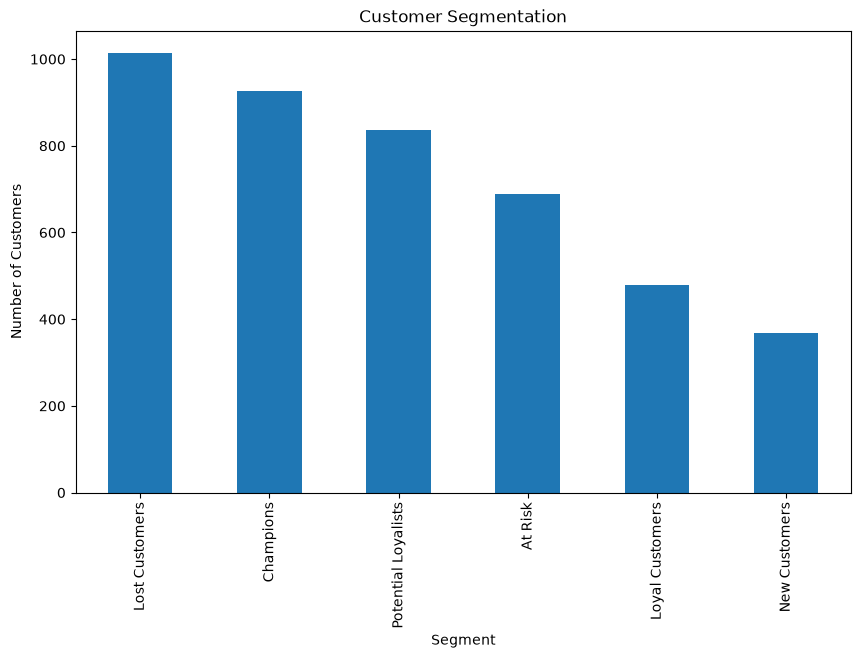

In [6]:
segment_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Customer Segmentation"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

## Segment Revenue

In [7]:
segment_revenue = (
    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(
        ascending=False
    )
)

segment_revenue

Segment
Champions              5712430.697
At Risk                1036709.791
Loyal Customers         845933.702
Potential Loyalists     611301.690
Lost Customers          408503.374
New Customers           183354.490
Name: Monetary, dtype: float64

## Identify Champions

In [8]:
champions = rfm[
    rfm["Segment"] == "Champions"
].sort_values(
    "Monetary",
    ascending=False
)

champions.head(20)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
4183,18102.0,1,89,349164.35,5,5,5,555,Champions
1637,14646.0,10,78,248396.50,5,5,5,555,Champions
1269,14156.0,7,102,196549.74,5,5,5,555,Champions
1840,14911.0,1,205,152121.22,5,5,5,555,Champions
939,13694.0,9,94,131443.19,5,5,5,555,Champions
3744,17511.0,3,31,84541.17,5,5,5,555,Champions
1951,15061.0,3,86,83284.38,5,5,5,555,Champions
3128,16684.0,15,27,80489.21,5,5,5,555,Champions
3177,16754.0,8,29,65500.07,5,5,5,555,Champions
4065,17949.0,7,74,60117.60,5,5,5,555,Champions
